Plot successfully saved to: ./repa_sit_train_losses.pdf


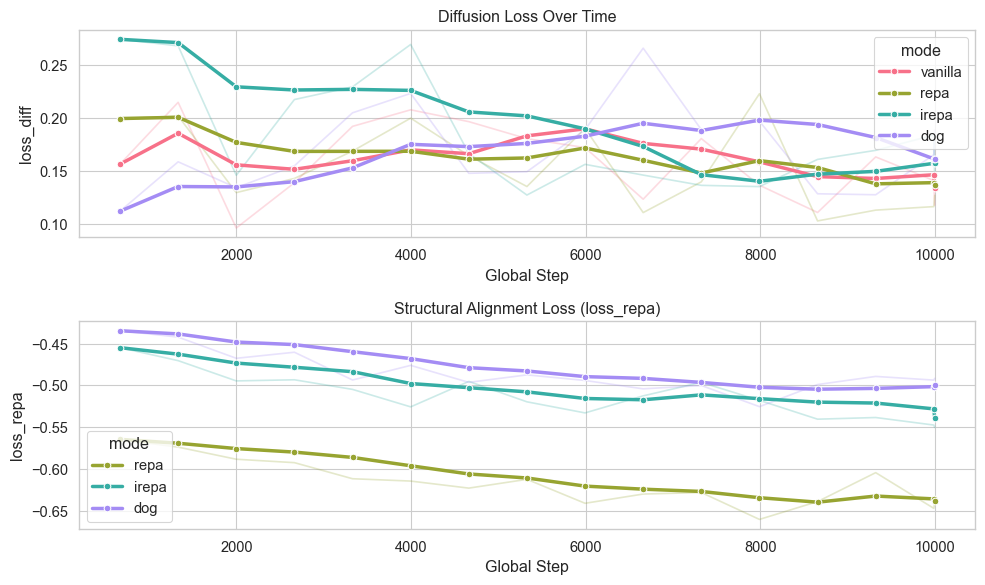

In [38]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_experiment_data(base_dir="./../results"):
    """Loads all JSON logs into a single Pandas DataFrame."""
    modes = ["vanilla", "repa", "irepa", "dog"]
    all_data = []

    for mode in modes:
        filepath = os.path.join(base_dir, f"sit_{mode}", f"experiment_log_sit_{mode}.json")
        if not os.path.exists(filepath):
            print(f"Warning: Could not find data for {mode} at {filepath}")
            continue

        with open(filepath, 'r') as f:
            data = json.load(f)
            df = pd.DataFrame(data)
            df['mode'] = mode
            all_data.append(df)

    if not all_data:
        raise ValueError("No data found. Check your base_dir path.")

    return pd.concat(all_data, ignore_index=True)

def add_moving_average(df, metrics, window_size=5):
    """
    Calculates moving average for specified metrics.
    Groups by 'mode' to prevent smoothing across different experiments.
    """
    for metric in metrics:
        if metric in df.columns:
            df[f"{metric}_smoothed"] = df.groupby('mode')[metric].transform(
                lambda x: x.rolling(window=window_size, min_periods=1).mean()
            )
    return df

def plot_results(df, window_size=5, save_path=None):
    """Generates the visualizations with moving average overlays."""
    # 1. Apply moving average to our line-plot metrics
    metrics_to_smooth = ["loss_diff", "fid_score", "ram_usage_mb", "loss_repa"]
    df = add_moving_average(df, metrics_to_smooth, window_size=window_size)

    # Set styling
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    modes_list = ["vanilla", "repa", "irepa", "dog"]
    husl_colors = sns.color_palette("husl", len(modes_list))
    color_map = dict(zip(modes_list, husl_colors))

    fig = plt.figure(figsize=(10, 6))
    # fig.suptitle(f"Diffusion Representational Alignment (Moving Average Window: {window_size})", fontsize=16, y=1.02)

    # Helper function to plot raw background + smoothed foreground
    def plot_smoothed_metric(ax, metric_name, title, ylabel, data_frame, plot_palette):
        # Raw data (faint)
        sns.lineplot(data=data_frame, x="global_step", y=metric_name, hue="mode",
                     palette=plot_palette, ax=ax, alpha=0.25, legend=False)
        # Smoothed data (bold)
        sns.lineplot(data=data_frame, x="global_step", y=f"{metric_name}_smoothed", hue="mode",
                     palette=plot_palette, ax=ax, linewidth=2.5, marker="o")
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Global Step")

    # 1. Compare loss_diff
    ax1 = plt.subplot(2, 1, 1)
    plot_smoothed_metric(ax1, "loss_diff", "Diffusion Loss Over Time", "loss_diff", df, color_map)

    # 2. Compare fid_score
    # ax2 = plt.subplot(2, 3, 2)
    # plot_smoothed_metric(ax2, "fid_score", "SiT FID Score Evaluation", "FID Score", df, palette)

    # 3. Compare ram_usage_mb
    # ax3 = plt.subplot(2, 3, 3)
    # plot_smoothed_metric(ax3, "ram_usage_mb", "System RAM Usage", "RAM (MB)", df, palette)

    # 4. Compare loss_repa (excluding vanilla)
    ax4 = plt.subplot(2, 1, 2)
    repa_df = df[df['mode'] != 'vanilla'].copy()
    plot_smoothed_metric(ax4, "loss_repa", "Structural Alignment Loss (loss_repa)", "loss_repa", repa_df, color_map)


    # 5. Time taken per step (Boxplot for Q1, Q3, Median/Mean)
    # Moving average doesn't apply to the distribution boxplot
    # ax5 = plt.subplot(1, 1, 1)
    # sns.boxplot(data=df, x="mode", y="avg_step_time_secs", hue="mode", palette=color_map,
    #             ax=ax5, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white"})
    # ax5.set_title("SiT Step Time Distribution")
    # ax5.set_ylabel("Average Step Time (Seconds)")
    # ax5.set_xlabel("Method")
    # else:
    #     sns.boxplot(data=df, x="mode", y="timestamp", hue="mode", palette=palette,
    #                 ax=ax5, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white"})
    #     ax5.set_title("Step Time Distribution")
    #     ax5.set_ylabel("Timestamp (Seconds)")
    #     ax5.set_xlabel("Method")
        # ax5.text(0.5, 0.5, "Timing data missing.\n(Check ExperimentLogger)",
        #          ha='center', va='center', fontsize=12, color='gray')
        # ax5.set_title("Step Time Distribution")
        # ax5.set_axis_off()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format="pdf")
        print(f"Plot successfully saved to: {save_path}")

    # Adjust layout
    plt.show()

if __name__ == "__main__":
    try:
        results_df = load_experiment_data()
        # You can adjust the window_size depending on how noisy your data is.
        # Since you evaluate ~60 times per run, a window of 5 is usually a good balance.
        plot_results(results_df, window_size=5, save_path="./repa_sit_train_losses.pdf")
    except Exception as e:
        print(f"Error visualizing data: {e}")

Loading checkpoint for vanilla on MPS...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 10415.24it/s]
/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Generating 3x3 image grid for vanilla...


/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/diffusers/models/transformers/transformer_2d.py:35: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)


Loading checkpoint for repa on MPS...


...

Generating 3x3 image grid for repa...
Loading checkpoint for irepa on MPS...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 11479.54it/s]


Generating 3x3 image grid for irepa...
Loading checkpoint for dog on MPS...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 12631.06it/s]


Generating 3x3 image grid for dog...
Generated image grid saved to: ./repa_sit_qualitative_generation.pdf


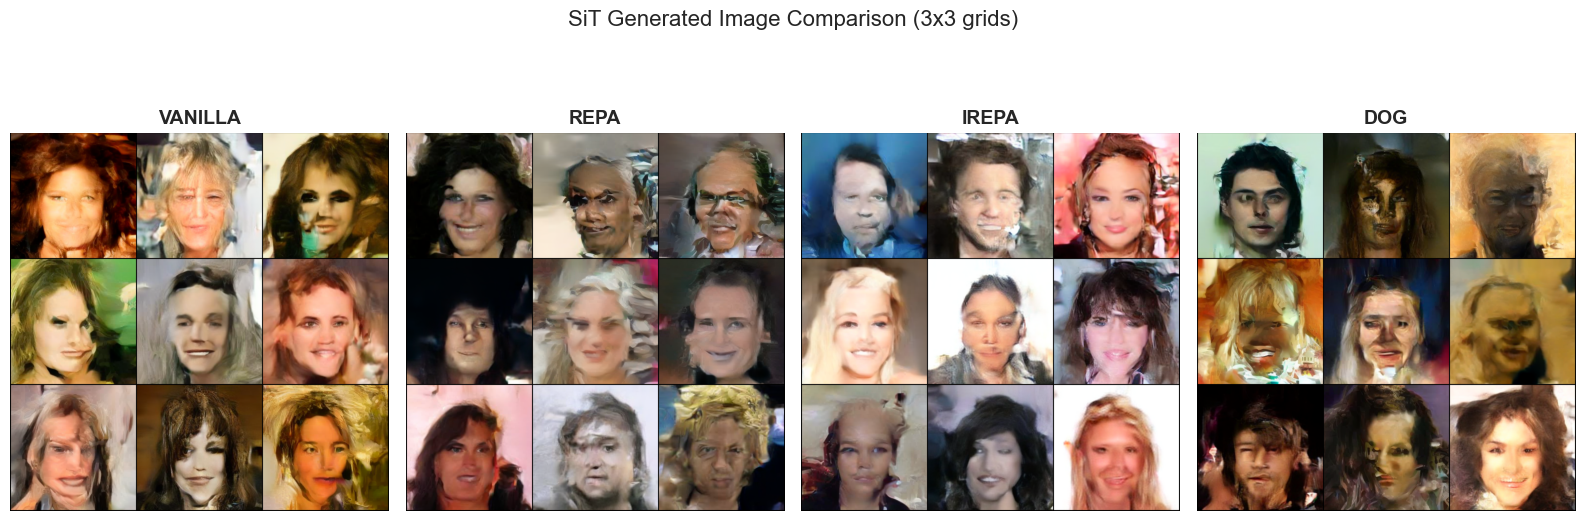

In [33]:
# notebook_code.py
import os
import glob
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from diffusers import DPMSolverMultistepScheduler
from dataclasses import dataclass

from repa.models.wrapper import REPAWrapper
from repa.models.factory import build_student_model
from repa.align.projection import ConvProjector, TokenProjector

@dataclass
class NotebookConfig:
    """Mock config to bypass argparse requirements in notebook environments."""
    mode: str
    model_type: str
    teacher_model_id: str = "facebook/dinov2-base"
    vae_model_id: str = "stabilityai/sd-vae-ft-mse"

def load_checkpoint(checkpoint_path: str, device: torch.device) -> REPAWrapper:
    # Load to CPU first to inspect metadata and prevent VRAM spikes
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    mode = checkpoint.get("mode", "repa")
    model_type = checkpoint.get("model_type", "sit")
    
    # 1. Initialize dependencies
    config = NotebookConfig(mode=mode, model_type=model_type)
    student_model, meta = build_student_model(model_type)
    
    wrapper = REPAWrapper(student_model=student_model, meta=meta, config=config)
    wrapper = wrapper.to(device)
    wrapper.eval()
    
    # 2. Load student
    wrapper.student.load_state_dict(checkpoint['student_state'])
    
    # 3. Dynamically reconstruct lazy projection head from saved dimensions
    if mode in ["repa", "irepa", "dog"] and 'proj_head_state' in checkpoint:
        state = checkpoint['proj_head_state']
        
        if 'conv.weight' in state:
            out_ch, in_ch, k, _ = state['conv.weight'].shape
            wrapper.proj_head = ConvProjector(in_ch, out_ch, kernel=k).to(device)
        elif 'mlp.0.weight' in state:
            in_dim = state['mlp.0.weight'].shape[1]
            out_dim = state['mlp.2.weight'].shape[0]
            wrapper.proj_head = TokenProjector(in_dim, out_dim).to(device)
            
        wrapper.proj_head.load_state_dict(state)
        
    # Cast entirely to native compute dtype (handles MPS/CUDA precision rules)
    wrapper = wrapper.to(wrapper.compute_dtype)
    return wrapper

@torch.no_grad()
def generate_image_grid(
    wrapper: REPAWrapper,
    grid_size: int = 3,
    num_inference_steps: int = 20,
    device: torch.device = torch.device("cpu")):
    
    wrapper.eval()
    
    scheduler = DPMSolverMultistepScheduler(
        num_train_timesteps=1000,
        beta_schedule="linear",
        algorithm_type="dpmsolver++"
    )
    
    latent_channels = wrapper.vae.latent_channels
    latent_h, latent_w = 32, 32
    batch_size = grid_size * grid_size
    compute_dtype = wrapper.compute_dtype
    
    # Instantiate latents natively in compute_dtype for MPS safety
    latents = torch.randn((batch_size, latent_channels, latent_h, latent_w), device=device, dtype=compute_dtype)
    scheduler.set_timesteps(num_inference_steps)
    
    # Restrict autocast to CUDA; MPS relies on tensor data types
    use_autocast = device.type == "cuda"
    context = torch.autocast(device_type=device.type, dtype=compute_dtype) if use_autocast else torch.no_grad()
    
    with context:
        for t in scheduler.timesteps:
            t_batch = torch.full(
                (batch_size,),
                t.item() if isinstance(t, torch.Tensor) else t,
                device=device,
                dtype=torch.long
            )
            class_labels = torch.full(
                (batch_size,),
                1000,
                device=device,
                dtype=torch.long
            )
            
            student_output = wrapper.forward_student(
                latents,
                timesteps=t_batch,
                class_labels=class_labels
            )
            
            output_sample = student_output.sample if hasattr(student_output, "sample") else student_output
            if output_sample.shape[1] == latent_channels * 2:
                noise_pred, _ = output_sample.chunk(2, dim=1)
            else:
                noise_pred = output_sample
            
            latents = scheduler.step(noise_pred, t, latents).prev_sample

    latents = latents / wrapper.vae.scaling_factor
    latents = latents.to(compute_dtype)
    images = wrapper.vae.decode(latents).sample
    images = (images.to(torch.float32) / 2 + 0.5).clamp(0, 1)
    
    return images

def visualize_generated_images(base_dir: str = "./results", grid_size: int = 3, save_path: str = None):
    modes = ["vanilla", "repa", "irepa", "dog"]
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
    
    generated_grids = {}
    
    for mode in modes:
        # Match standard save pattern: checkpoint_best_{model_type}_{mode}.pt
        search_pattern = os.path.join(base_dir, f"sit_{mode}", f"checkpoint_best_*_{mode}.pt")
        checkpoints = glob.glob(search_pattern)
        
        if not checkpoints:
            checkpoint_path = os.path.join(base_dir, mode, f"checkpoint_best_{mode}.pt")
        else:
            checkpoint_path = checkpoints[0]
            
        if not os.path.exists(checkpoint_path):
            print(f"Warning: Checkpoint not found for {mode} at {checkpoint_path}")
            continue
        
        print(f"Loading checkpoint for {mode} on {device.type.upper()}...")
        wrapper = load_checkpoint(checkpoint_path, device)
        
        print(f"Generating {grid_size}x{grid_size} image grid for {mode}...")
        images = generate_image_grid(wrapper, grid_size=grid_size, device=device)
        
        grid = make_grid(images, nrow=grid_size, normalize=False, pad_value=0)
        generated_grids[mode] = grid
        
        del wrapper
        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()
            
    if not generated_grids:
        print("No generated grids to display.")
        return

    fig, axes = plt.subplots(1, len(generated_grids), figsize=(16, 6))
    if len(generated_grids) == 1:
        axes = [axes]
    
    for idx, (mode, grid) in enumerate(generated_grids.items()):
        grid_np = grid.cpu().permute(1, 2, 0).numpy()
        axes[idx].imshow(grid_np)
        axes[idx].set_title(f"{mode.upper()}", fontsize=14, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"SiT Generated Image Comparison ({grid_size}x{grid_size} grids)", fontsize=16, y=1.02)
    
    if save_path:
        plt.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"Generated image grid saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    visualize_generated_images(base_dir="./../results", grid_size=3, save_path="./repa_sit_qualitative_generation.pdf")